# Part F 확장 — 시가 품질 · F2 안정성 · ETF 비용 우회 · 동조화 연결
원 분석: `shipbuilding_crossasset.ipynb` Part F (결과 `results_cross/`). 이 노트북은 **원 노트북과 결과 파일을 건드리지 않고** 결과를 `results/F_ext/`에 저장합니다.

- 주가: 원 Part F와 같은 네이버 수정주가(pykrx), KOSPI는 FDR `KS11`, 미국은 yfinance(`auto_adjust=True`)
- **신호 정의·바스켓·시점 정렬·회귀·전략 코드는 원 Part F에서 그대로 복사**함 (아래 "원 Part F 코드" 셀)
- 표본 끝: 원 Part F와 같은 2026-09-17 (재현 확인용으로 고정)

| 단계 | 내용 |
|---|---|
| Step 0 | 슬라이드용 숫자 추출 (기존 결과 파일에서, 새 계산 없음) |
| Step 1 | 시가 데이터 품질 점검 — 문제가 F2 결론을 바꾸면 여기서 멈춤 |
| Step 2 | F2 안정성 (연도별, 신호 구성, 전·후반) |
| Step 3 | 거래세 없는 ETF로 우회하면 비용 후 수익이 남는가 |
| Step 4 | 동조화(V1) High일 때 신호 전달이 강한가 — 사전 지정 검정 1개 |

In [1]:
import os, time, re, warnings, io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import requests
from scipy import stats
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
pd.set_option("display.width", 220); pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110

RES_DIR = os.path.join("results", "F_ext"); os.makedirs(RES_DIR, exist_ok=True)
START = "2015-01-01"
END   = "2026-09-25"          # 원 Part F 실행일 (재현용)
F_END = "2026-09-17"          # 원 Part F 표본의 마지막 날 (FDR KS11 기준) — 모든 분석을 여기서 끝냄
DART_API_KEY = os.environ.get("DART_API_KEY", "")   # 환경변수에서만 읽음 (키를 노트북·출력에 남기지 않음)
assert DART_API_KEY.strip(), "환경변수 DART_API_KEY가 비어 있습니다 — 진행하지 않음"
_redact = lambda s: str(s).replace(DART_API_KEY, "***")

# ---- 원 Part F 설정 그대로 ----
SHIP     = {"329180": "HD HHI", "010620": "HD Mipo", "010140": "Samsung HI", "042660": "Hanwha Ocean"}
SHIP_ALL = {"009540": "HD KSOE", **SHIP}
US_SIGNAL  = {"LNG": "Cheniere (US LNG exporter)", "HII": "Huntington Ingalls (US shipbuilder)",
              "ZIM": "ZIM (container shipping)"}
US_EXTRA   = {"BZ=F": "Brent crude"}
US_CONTROL = {"^GSPC": "S&P 500"}
COST_BUY  = 0.00015
COST_SELL = 0.00015 + 0.0015          # 원 노트북 값(2025년 세율) — 재현용
COST_SELL_2026 = 0.00015 + 0.0020     # 2026년 코스피 매도세 0.20% (거래세 0.05% + 농특세 0.15%)

In [2]:
# ---- 원 Part F 코드 (shipbuilding_crossasset.ipynb에서 그대로 복사) ----
def load_ohlc(ticker, start, end):
    s, e = start.replace("-", ""), end.replace("-", "")
    try:
        from pykrx import stock
        df = stock.get_market_ohlcv(s, e, ticker)
        if df is not None and not df.empty:
            df = df.rename(columns={"시가": "Open", "종가": "Close", "거래량": "Volume"})
            return df[["Open", "Close", "Volume"]].astype(float)
    except Exception as ex:
        print(f"  pykrx 실패({ticker}): {ex}")
    try:
        import FinanceDataReader as fdr
        df = fdr.DataReader(ticker, start, end)
        if df is not None and not df.empty:
            print(f"  FDR 사용({ticker})")
            return df[["Open", "Close", "Volume"]].astype(float)
    except Exception as ex:
        print(f"  FDR 실패({ticker}): {ex}")
    return None

def load_kospi_ohlc(start, end):
    try:
        from pykrx import stock
        df = stock.get_index_ohlcv(start.replace("-", ""), end.replace("-", ""), "1001")
        if df is not None and not df.empty:
            return df.rename(columns={"시가": "Open", "종가": "Close"})[["Open", "Close"]].astype(float)
    except Exception as ex:
        print(f"  pykrx 지수 실패: {ex}")
    import FinanceDataReader as fdr
    return fdr.DataReader("KS11", start, end)[["Open", "Close"]].astype(float)

def load_panel(names, start, end):
    O, C, V = {}, {}, {}
    for t in names:
        df = load_ohlc(t, start, end)
        if df is None:
            print(f"  -> {t} 제외"); continue
        df.index = pd.to_datetime(df.index)
        O[t], C[t], V[t] = df["Open"], df["Close"], df["Volume"]
        time.sleep(0.3)
    return pd.DataFrame(O), pd.DataFrame(C), pd.DataFrame(V)

def kr_returns(O, C, V, cap=0.305):
    halt = (V == 0) | V.isna() | (O <= 0)
    cc = C.pct_change(fill_method=None)
    gap = O / C.shift(1) - 1
    intra = C / O - 1
    bad = halt | (cc.abs() > cap) | (gap.abs() > cap) | (intra.abs() > cap)
    n_bad = int((bad & ~halt).values.sum())
    if n_bad:
        print(f"  비정상 수익률 {n_bad}개 NaN 처리 (수정주가 기준 불일치 가능 → 확인 필요)")
    return cc.mask(bad), gap.mask(bad), intra.mask(bad)

def basket(df, cols):
    cols = [c for c in cols if c in df.columns]
    return df[cols].mean(axis=1, skipna=True)

def align_us_to_kr(us_ret, kr_dates):
    us_idx = us_ret.index
    out = np.full((len(kr_dates), us_ret.shape[1]), np.nan)
    prev = kr_dates[0] - pd.Timedelta(days=5)
    for i, k in enumerate(kr_dates):
        m = (us_idx >= prev) & (us_idx < k)
        if m.any():
            out[i] = us_ret.loc[m].sum(min_count=1).values
        prev = k
    return pd.DataFrame(out, index=kr_dates, columns=us_ret.columns)

def hac_ols(y, X, lags=5):
    d = pd.concat([y, X], axis=1).dropna()
    res = sm.OLS(d.iloc[:, 0], sm.add_constant(d.iloc[:, 1:])).fit(cov_type="HAC", cov_kwds={"maxlags": lags})
    return res

def metrics(r, name=""):
    r = r.dropna()
    if len(r) < 60: return {"strategy": name}
    yrs = len(r) / 252; cum = (1 + r).prod()
    cagr = cum ** (1 / yrs) - 1; vol = r.std() * np.sqrt(252)
    eq = (1 + r).cumprod(); mdd = (eq / eq.cummax() - 1).min()
    return {"strategy": name, "CAGR(%)": cagr * 100, "Vol(%)": vol * 100,
            "Sharpe": cagr / vol if vol > 0 else np.nan, "MDD(%)": mdd * 100, "Days": len(r)}

In [3]:
# ---- 데이터 (원 Part F와 같은 방식) + 원 결과 재현 확인 ----
kospi = load_kospi_ohlc(START, END); kospi.index = pd.to_datetime(kospi.index)
kospi = kospi.loc[:F_END]
CAL = kospi.index
O, C, V = load_panel(SHIP_ALL, START, END)
PANEL = (O.reindex(CAL), C.reindex(CAL), V.reindex(CAL))
Rs = kr_returns(*PANEL)
k_cc    = kospi["Close"].pct_change(fill_method=None)
k_gap   = kospi["Open"] / kospi["Close"].shift(1) - 1
k_intra = kospi["Close"] / kospi["Open"] - 1
ship_cols = list(SHIP.keys())

def make_B(Rs):
    return pd.DataFrame({"ship_cc_ex": basket(Rs[0], ship_cols) - k_cc,
                         "ship_gap_ex": basket(Rs[1], ship_cols) - k_gap,
                         "ship_intra_ex": basket(Rs[2], ship_cols) - k_intra,
                         "ship_intra": basket(Rs[2], ship_cols), "kospi_cc": k_cc})
B = make_B(Rs)

import yfinance as yf
us_tickers = list(US_SIGNAL) + list(US_EXTRA) + list(US_CONTROL)
raw_us = yf.download(us_tickers, start=START, end=END, auto_adjust=True, progress=False)["Close"]
if isinstance(raw_us, pd.Series):
    raw_us = raw_us.to_frame(us_tickers[0])
raw_us.index = pd.to_datetime(raw_us.index).tz_localize(None)
for t in [c for c in us_tickers if c not in raw_us.columns or raw_us[c].notna().sum() == 0]:
    for _ in range(3):
        time.sleep(2)
        s = yf.download(t, start=START, end=END, auto_adjust=True, progress=False)["Close"]
        if isinstance(s, pd.DataFrame): s = s.iloc[:, 0]
        if s.notna().sum() > 0:
            s.index = pd.to_datetime(s.index).tz_localize(None); raw_us[t] = s; break
    assert raw_us[t].notna().sum() > 0, f"{t} 데이터 수신 실패"
us_ret = np.log(raw_us).apply(lambda s: s.dropna().diff()).reindex(raw_us.index)
usk = align_us_to_kr(us_ret, CAL)
sig_cols = [c for c in US_SIGNAL if c in usk.columns]

def make_F(B, cols=sig_cols):
    F = B.copy()
    F["us_ship"] = usk[cols].mean(axis=1, skipna=True)
    F["spx"] = usk["^GSPC"]; F["brent"] = usk["BZ=F"]
    F["signal"] = F["us_ship"] - F["spx"]
    return F
F = make_F(B)

def f1_table(F):
    rows = []
    for target in ["ship_gap_ex", "ship_intra_ex", "ship_cc_ex"]:
        res = hac_ols(F[target], F[["us_ship", "spx", "brent"]])
        for v in ["us_ship", "spx", "brent"]:
            rows.append({"target": target, "var": v, "coef": res.params[v], "HAC t": res.tvalues[v],
                         "R2": res.rsquared, "N": int(res.nobs)})
    return pd.DataFrame(rows).set_index(["target", "var"])
tblF1 = f1_table(F)
orig = pd.read_csv("results_cross/F1_regression.csv").set_index(["target", "var"])   # 읽기만 함
rep = tblF1[["coef", "HAC t", "N"]].join(orig[["coef", "HAC t", "N"]], rsuffix=" (원본)")
display(rep)
print("원본 대비 최대 차이 — coef:", float((rep["coef"] - rep["coef (원본)"]).abs().max()),
      "| t:", float((rep["HAC t"] - rep["HAC t (원본)"]).abs().max()), "| N 동일:", bool((rep["N"] == rep["N (원본)"]).all()))

rank = F["signal"].expanding(min_periods=250).rank(pct=True)
on = (rank >= 0.8).astype(float)
print(f"F3 재현: 신호일 {int(on.sum())}일, 신호일 평균 장중 수익 {F.loc[on > 0, 'ship_intra'].mean()*100:.3f}% "
      f"(원 보고서 598일, 0.236%)")

KRX 로그인 실패: KRX_ID 또는 KRX_PW 환경 변수가 설정되지 않았습니다.
Error occurred in get_index_ohlcv_by_date: Expecting value: line 1 column 1 (char 0)


Error occurred in __fetch: Expecting value: line 1 column 1 (char 0)
  pykrx 지수 실패: '지수명'


coef   HAC t     N  coef (원본)  HAC t (원본)  N (원본)
target        var                                                         
ship_gap_ex   us_ship  0.0224  1.5384  2780     0.0224      1.5384    2780
              spx      0.0915  4.3065  2780     0.0915      4.3065    2780
              brent    0.0457  3.9586  2780     0.0457      3.9586    2780
ship_intra_ex us_ship  0.1029  3.6768  2780     0.1029      3.6767    2780
              spx     -0.2031 -4.6388  2780    -0.2031     -4.6388    2780
              brent    0.0560  3.3638  2780     0.0560      3.3638    2780
ship_cc_ex    us_ship  0.1252  4.2518  2780     0.1252      4.2518    2780
              spx     -0.1080 -2.2828  2780    -0.1080     -2.2828    2780
              brent    0.1015  5.4849  2780     0.1015      5.4849    2780

원본 대비 최대 차이 — coef: 5.82825638389961e-07 | t: 1.8762983863496174e-05 | N 동일: True
F3 재현: 신호일 598일, 신호일 평균 장중 수익 0.236% (원 보고서 598일, 0.236%)


In [4]:
# ---- Step 0. 슬라이드용 숫자 (기존 결과 파일에서 읽기만, 새 계산 없음) ----
import nbformat, json as _json
i2 = pd.read_csv("results/leadlag_pairs/I2_predictive_regressions.csv")
i1 = pd.read_csv("results/leadlag_pairs/I1_ccf_asymmetry.csv")
f3 = pd.read_csv("results_cross/F3_strategy.csv")
nb_x = nbformat.read("results_cross/shipbuilding_crossasset_executed.ipynb", 4)
f3_line = [o.text for c in nb_x.cells if c.cell_type == "code" and "avg_gain" in c.source
           for o in c.outputs if o.output_type == "stream"]
f3_line = re.search(r"신호일 평균 장중 수익 ([\d.]+)% vs 왕복비용 ([\d.]+)%", "".join(f3_line))
j5 = pd.read_csv("results/leadlag_pairs/J5_compare_partD.csv")

S0 = []
for _, r in i2[i2["test"].str.startswith("I-3")].iterrows():
    S0.append({"항목": "(a) Part I 플라시보 (삼성전자 → 기자재)", "구분": f"{r['freq']} · {r['universe']}",
               "값": f"Σb = {r['Σb']:+.3f}, p = {r['Σb p']:.3f} (결합 F p = {r['joint F p (b=0)']:.3f}, N = {r['N']})",
               "출처": "results/leadlag_pairs/I2_predictive_regressions.csv"})
for _, r in i2[i2["freq"] == "일간"].iterrows():
    if r["test"].startswith("I-3"): continue
    S0.append({"항목": "(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함)", "구분": f"{r['test']} · {r['universe']}",
               "값": f"Σb = {r['Σb']:+.3f}, t = {r['Σb t']:.2f}, p = {r['Σb p']:.3f}, 결합 F p = {r['joint F p (b=0)']:.3f}",
               "출처": "I2_predictive_regressions.csv"})
for _, r in i1[i1["freq"] == "일간"].iterrows():
    S0.append({"항목": "(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함)", "구분": f"I-1 교차상관 비대칭 · {r['universe']}",
               "값": f"Σ(조선→기자재) − Σ(기자재→조선) = {r['Σ(L→F) − Σ(F→L)']:+.3f}, p = {r['p']:.3f}",
               "출처": "I1_ccf_asymmetry.csv"})
S0.append({"항목": "(c) Part F3 신호일(상위 20%)", "구분": "신호일 평균 장중 수익 / 신호일 수",
           "값": f"{f3_line.group(1)}% / {int(f3.loc[0, 'trade days'])}일 (당시 왕복비용 가정 {f3_line.group(2)}%)",
           "출처": "results_cross/F3_strategy.csv + 실행본 노트북 출력"})
S0.append({"항목": "(d) Part J 비용 가정", "구분": "매수 / 매도 / 대차",
           "값": "수수료 매수·매도 각 0.015%, 거래세 0.20%(롱 청산 매도와 공매도 매도에 부과), 숏 대차수수료 연 3%(252일 일할)",
           "출처": "results/leadlag_pairs/PartJ_summary.md, J5_compare_partD.csv"})
S0.append({"항목": "(d) Part J 세율 근거", "구분": "2026년 코스피 거래세 0.05% + 농특세 0.15% = 0.20% (코스닥 0.20%)",
           "값": "결과 파일에는 세율 값만 있고 출처 URL은 적혀 있지 않음. 당시 보고에 쓴 출처: 네이트 뉴스 2025-12-01 "
                 "'내년부터 증권거래세 인상…코스피 0.05%·코스닥 0.20%', 머니투데이 2025-12-01",
           "출처": "https://news.nate.com/view/20251201n26338 , https://www.mt.co.kr/economy/2025/12/01/2025120108471236062"})
S0 = pd.DataFrame(S0)
S0.to_csv(f"{RES_DIR}/S0_slide_numbers.csv", index=False, encoding="utf-8-sig")
display(S0)

,항목,구분,값,출처
0,(a) Part I 플라시보 (삼성전자 → 기자재),주간 · 6종목(본 분석),"Σb = -0.075, p = 0.669 (결합 F p = 0.949, N = 533)",results/leadlag_pairs/I2_predictive_regressions.csv
1,(a) Part I 플라시보 (삼성전자 → 기자재),일간 · 6종목(본 분석),"Σb = +0.017, p = 0.795 (결합 F p = 0.908, N = 2863)",results/leadlag_pairs/I2_predictive_regressions.csv
2,(a) Part I 플라시보 (삼성전자 → 기자재),주간 · 8종목(강건성),"Σb = -0.008, p = 0.968 (결합 F p = 0.967, N = 533)",results/leadlag_pairs/I2_predictive_regressions.csv
3,(a) Part I 플라시보 (삼성전자 → 기자재),일간 · 8종목(강건성),"Σb = +0.044, p = 0.501 (결합 F p = 0.965, N = 2863)",results/leadlag_pairs/I2_predictive_regressions.csv
4,(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함),I-2 조선→기자재 · 6종목(본 분석),"Σb = +0.041, t = 0.92, p = 0.359, 결합 F p = 0.462",I2_predictive_regressions.csv
5,(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함),I-4 역방향 기자재→조선 · 6종목(본 분석),"Σb = +0.194, t = 2.94, p = 0.003, 결합 F p = 0.046",I2_predictive_regressions.csv
6,(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함),I-2 조선→기자재 · 8종목(강건성),"Σb = +0.033, t = 0.70, p = 0.483, 결합 F p = 0.858",I2_predictive_regressions.csv
7,(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함),I-4 역방향 기자재→조선 · 8종목(강건성),"Σb = +0.160, t = 2.80, p = 0.005, 결합 F p = 0.062",I2_predictive_regressions.csv
8,(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함),I-1 교차상관 비대칭 · 6종목(본 분석),"Σ(조선→기자재) − Σ(기자재→조선) = -0.042, p = 0.306",I1_ccf_asymmetry.csv
9,(b) Part I 일간 보조 (시차 1~4일; 5일은 계산 안 함),I-1 교차상관 비대칭 · 8종목(강건성),"Σ(조선→기자재) − Σ(기자재→조선) = -0.008, p = 0.859",I1_ccf_asymmetry.csv


---
## Step 1. 시가 데이터 품질 점검
F2(미국 신호 → 장중, t = 3.68)는 시가가 틀어지면 무효임. 원 Part F 바스켓 4종목(HD현대중공업, HD현대미포, 삼성중공업, 한화오션)을 점검함.

- **수정 시세**: pykrx(네이버 수정주가) 시가·고가·저가·종가 — 원 Part F가 쓴 것과 같은 출처
- **수정 전 시세**: 네이버 모바일 시세 API의 openPrice·highPrice·lowPrice·closePrice (Step 0 거래대금에 쓴 것과 같은 출처)
  - HD현대미포(2025-12 상장폐지)는 네이버·Yahoo 모두 수정 전 시세를 더 이상 제공하지 않음 → 1-2는 점검 불가. 대신 DART 자본 변동 공시로 수정 이벤트 유무를 확인함.
- **판정 기준 (미리 정함)**: 1-2·1-3에 걸린 종목·일을 빼고 다시 돌린 F2(장중) us_ship 계수가 양수이고 HAC t ≥ 2.39(원 보고서의 세 종속변수 Bonferroni 기준)이면 "결론 유지".
- 허용 오차: 수정주가는 원 단위 반올림이라, 시가·종가 수정 비율 차이가 1/수정시가 + 1/수정종가 이하이면 반올림 오차로 봄.

In [5]:
# ---- Step 1-0. 수정 / 수정 전 OHLC ----
from pykrx import stock
HDR = {"User-Agent": "Mozilla/5.0"}
def naver_raw_daily(code, start=START, page_size=60, max_pages=400):
    rows = []
    for page in range(1, max_pages + 1):
        r = requests.get(f"https://m.stock.naver.com/api/stock/{code}/price",
                         params={"pageSize": page_size, "page": page}, headers=HDR, timeout=20)
        js = r.json()
        if not isinstance(js, list) or not js: break
        rows += js
        if js[-1]["localTradedAt"] < start: break
        time.sleep(0.12)
    if not rows: return None
    df = pd.DataFrame(rows); df["date"] = pd.to_datetime(df["localTradedAt"])
    for k in ["open", "high", "low", "close"]:
        df[k] = df[f"{k}Price"].astype(str).str.replace(",", "").astype(float)
    df["vol"] = df["accumulatedTradingVolume"].astype(float)
    return df.set_index("date").sort_index().loc[start:, ["open", "high", "low", "close", "vol"]]

ADJ, RAW = {}, {}
for c in SHIP:
    a = stock.get_market_ohlcv(START.replace("-", ""), END.replace("-", ""), c)
    a.index = pd.to_datetime(a.index)
    ADJ[c] = a.rename(columns={"시가": "open", "고가": "high", "저가": "low", "종가": "close", "거래량": "vol"})[
        ["open", "high", "low", "close", "vol"]].astype(float).reindex(CAL)
    rw = naver_raw_daily(c); RAW[c] = rw.reindex(CAL) if rw is not None else None
    time.sleep(0.3)
print({SHIP[c]: ("수정 전 시세 없음" if RAW[c] is None else f"수정 전 {int(RAW[c]['close'].notna().sum())}일") for c in SHIP})
print("원 Part F 패널과 수정 시가·종가 일치:",
      {SHIP[c]: bool(np.allclose(ADJ[c]["open"].fillna(-1), PANEL[0][c].fillna(-1)) and
                     np.allclose(ADJ[c]["close"].fillna(-1), PANEL[1][c].fillna(-1))) for c in SHIP})

{'HD HHI': '수정 전 1222일', 'HD Mipo': '수정 전 시세 없음', 'Samsung HI': '수정 전 2875일', 'Hanwha Ocean': '수정 전 2875일'}
원 Part F 패널과 수정 시가·종가 일치: {'HD HHI': True, 'HD Mipo': True, 'Samsung HI': True, 'Hanwha Ocean': True}


In [6]:
# ---- Step 1-1. 저가 ≤ 시가 ≤ 고가 (거래일 기준), 종가도 함께 ----
rows, viol = [], []
for c in SHIP:
    for lab, df in [("수정", ADJ[c]), ("수정 전", RAW[c])]:
        if df is None:
            rows.append({"종목": SHIP[c], "시세": lab, "거래일": np.nan}); continue
        t = df[df["vol"] > 0]
        v_open = (t["open"] < t["low"]) | (t["open"] > t["high"])
        v_close = (t["close"] < t["low"]) | (t["close"] > t["high"])
        v_zero = (t[["open", "high", "low", "close"]] <= 0).any(axis=1)
        over = pd.concat([(t["low"] - t["open"]).clip(lower=0), (t["open"] - t["high"]).clip(lower=0),
                          (t["low"] - t["close"]).clip(lower=0), (t["close"] - t["high"]).clip(lower=0)], axis=1).max(axis=1)
        rows.append({"종목": SHIP[c], "시세": lab, "거래일": len(t), "시가 범위 위반": int(v_open.sum()),
                     "종가 범위 위반": int(v_close.sum()), "0 이하 가격": int(v_zero.sum()),
                     "위반 최대 크기(원)": float(over.max()), "위반 중 1원 이하": int(((over > 0) & (over <= 1)).sum())})
        for d in t.index[v_open | v_close | v_zero]:
            viol.append({"종목": SHIP[c], "시세": lab, "date": d.date(), **t.loc[d, ["open", "high", "low", "close", "vol"]].to_dict()})
# KOSPI 지수 시가 (FDR KS11: 고가·저가 포함)
import FinanceDataReader as fdr
kx = fdr.DataReader("KS11", START, END).loc[:F_END]
vk = (kx["Open"] < kx["Low"]) | (kx["Open"] > kx["High"])
rows.append({"종목": "KOSPI 지수", "시세": "FDR KS11", "거래일": len(kx), "시가 범위 위반": int(vk.sum()),
             "종가 범위 위반": int(((kx["Close"] < kx["Low"]) | (kx["Close"] > kx["High"])).sum()),
             "0 이하 가격": int((kx[["Open", "High", "Low", "Close"]] <= 0).any(axis=1).sum())})
for d in kx.index[vk]:
    viol.append({"종목": "KOSPI 지수", "시세": "FDR KS11", "date": d.date(), "open": kx.loc[d, "Open"], "high": kx.loc[d, "High"],
                 "low": kx.loc[d, "Low"], "close": kx.loc[d, "Close"], "vol": kx.loc[d, "Volume"]})
S11 = pd.DataFrame(rows); S11v = pd.DataFrame(viol)
S11.to_csv(f"{RES_DIR}/S1_1_ohlc_range_check.csv", index=False, encoding="utf-8-sig")
S11v.to_csv(f"{RES_DIR}/S1_1_ohlc_range_violations.csv", index=False, encoding="utf-8-sig")
display(S11)
print("위반 목록:" if len(S11v) else "위반 없음");
if len(S11v): display(S11v)

,종목,시세,거래일,시가 범위 위반,종가 범위 위반,0 이하 가격,위반 최대 크기(원),위반 중 1원 이하
0,HD HHI,수정,"1,222.0000",0.0000,0.0000,0.0000,0.0000,0.0000
1,HD HHI,수정 전,"1,222.0000",0.0000,0.0000,0.0000,0.0000,0.0000
2,HD Mipo,수정,"2,677.0000",0.0000,14.0000,0.0000,1.0000,14.0000
3,HD Mipo,수정 전,NaN,NaN,NaN,NaN,NaN,NaN
4,Samsung HI,수정,"2,863.0000",0.0000,51.0000,0.0000,4.0000,20.0000
5,Samsung HI,수정 전,"2,863.0000",0.0000,0.0000,0.0000,0.0000,0.0000
6,Hanwha Ocean,수정,"2,560.0000",0.0000,0.0000,0.0000,0.0000,0.0000
7,Hanwha Ocean,수정 전,"2,560.0000",0.0000,0.0000,0.0000,0.0000,0.0000
8,KOSPI 지수,FDR KS11,"2,875.0000",0.0000,0.0000,0.0000,NaN,NaN


위반 목록:


,종목,시세,date,open,high,low,close,vol
0,HD Mipo,수정,2015-01-27,"34,842.0000","35,594.0000","34,842.0000","35,595.0000","211,759.0000"
1,HD Mipo,수정,2015-03-06,"40,257.0000","41,610.0000","39,755.0000","41,611.0000","206,137.0000"
2,HD Mipo,수정,2015-07-09,"32,536.0000","33,689.0000","32,185.0000","33,690.0000","135,709.0000"
3,HD Mipo,수정,2015-09-09,"28,275.0000","28,776.0000","28,024.0000","28,777.0000","138,854.0000"
4,HD Mipo,수정,2015-12-03,"31,584.0000","32,235.0000","31,182.0000","32,236.0000","52,888.0000"
...,...,...,...,...,...,...,...,...
60,Samsung HI,수정,2020-06-03,"5,833.0000","6,578.0000","5,785.0000","6,579.0000","118,886,609.0000"
61,Samsung HI,수정,2021-01-04,"6,692.0000","6,889.0000","6,588.0000","6,891.0000","19,724,311.0000"
62,Samsung HI,수정,2021-03-19,"6,059.0000","6,144.0000","6,021.0000","6,145.0000","3,536,615.0000"
63,Samsung HI,수정,2021-08-10,"6,173.0000","6,294.0000","5,892.0000","6,295.0000","11,386,585.0000"


In [7]:
# ---- Step 1-2. 같은 날 시가·종가에 적용된 수정 비율이 같은가 ----
rows, mis = [], []
FAC = {}
for c in SHIP:
    if RAW[c] is None:
        rows.append({"종목": SHIP[c], "비교 가능일": 0, "불일치일": np.nan, "비고": "수정 전 시세 없음(상장폐지) — 점검 불가"}); continue
    a, r = ADJ[c], RAW[c]
    ok = (a["vol"] > 0) & (r["vol"] > 0) & (r["open"] > 0) & (r["close"] > 0) & (a["open"] > 0)
    fo, fc = (a["open"] / r["open"])[ok], (a["close"] / r["close"])[ok]
    FAC[c] = fc
    dev = (fo / fc - 1).abs()
    tol = 1 / a["open"][ok] + 1 / a["close"][ok]
    bad = dev > tol
    sgn = (fo / fc - 1)[bad]
    rows.append({"종목": SHIP[c], "비교 가능일": int(ok.sum()), "불일치일": int(bad.sum()),
                 "불일치일 기간": f"{bad[bad].index.min().date()} ~ {bad[bad].index.max().date()}" if bad.any() else "",
                 "불일치일 평균 (시가비율/종가비율 − 1)": float(sgn.mean()) if bad.any() else np.nan,
                 "불일치일 중 음수 비율": float((sgn < 0).mean()) if bad.any() else np.nan,
                 "|시가비율/종가비율 − 1| 중앙값": float(dev.median()), "최대": float(dev.max()),
                 "수정 비율 ≠ 1인 날": int(((fc - 1).abs() > 1 / a["close"][ok]).sum()), "비고": ""})
    for d in dev.index[bad]:
        mis.append({"종목": SHIP[c], "code": c, "date": d, "수정 시가": a.loc[d, "open"], "수정 전 시가": r.loc[d, "open"],
                    "수정 종가": a.loc[d, "close"], "수정 전 종가": r.loc[d, "close"],
                    "시가 비율": fo[d], "종가 비율": fc[d], "차이": dev[d]})
S12 = pd.DataFrame(rows); S12m = pd.DataFrame(mis)
S12.to_csv(f"{RES_DIR}/S1_2_adjust_ratio_check.csv", index=False, encoding="utf-8-sig")
S12m.to_csv(f"{RES_DIR}/S1_2_adjust_ratio_mismatch_days.csv", index=False, encoding="utf-8-sig")
display(S12)
print(f"불일치 {len(S12m)}건" + (":" if len(S12m) else ""))
print("※ 시가비율/종가비율 − 1 = d이면, 그날 수정 기준 갭은 약 d만큼, 장중 수익률은 약 −d만큼 수정 전 기준과 달라짐")
if len(S12m): display(S12m.drop(columns="code"))

,종목,비교 가능일,불일치일,불일치일 기간,불일치일 평균 (시가비율/종가비율 − 1),불일치일 중 음수 비율,|시가비율/종가비율 − 1| 중앙값,최대,수정 비율 ≠ 1인 날,비고
0,HD HHI,1222,0.0000,,NaN,NaN,0.0000,0.0000,0.0000,
1,HD Mipo,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,수정 전 시세 없음(상장폐지) — 점검 불가
2,Samsung HI,2863,421.0000,2015-01-02 ~ 2021-06-25,-0.0003,1.0000,0.0001,0.0007,"1,640.0000",
3,Hanwha Ocean,2560,0.0000,,NaN,NaN,0.0000,0.0001,"1,835.0000",


불일치 421건:
※ 시가비율/종가비율 − 1 = d이면, 그날 수정 기준 갭은 약 d만큼, 장중 수익률은 약 −d만큼 수정 전 기준과 달라짐


,종목,date,수정 시가,수정 전 시가,수정 종가,수정 전 종가,시가 비율,종가 비율,차이
0,Samsung HI,2015-01-02,"14,384.0000","19,900.0000","14,207.0000","19,650.0000",0.7228,0.7230,0.0003
1,Samsung HI,2015-01-06,"13,336.0000","18,450.0000","13,158.0000","18,200.0000",0.7228,0.7230,0.0002
2,Samsung HI,2015-01-07,"13,047.0000","18,050.0000","13,231.0000","18,300.0000",0.7228,0.7230,0.0002
3,Samsung HI,2015-01-08,"13,372.0000","18,500.0000","13,231.0000","18,300.0000",0.7228,0.7230,0.0003
4,Samsung HI,2015-01-12,"13,698.0000","18,950.0000","13,592.0000","18,800.0000",0.7228,0.7230,0.0002
...,...,...,...,...,...,...,...,...,...
416,Samsung HI,2020-12-11,"6,653.0000","7,050.0000","6,759.0000","7,160.0000",0.9437,0.9440,0.0003
417,Samsung HI,2021-04-21,"6,842.0000","7,250.0000","6,731.0000","7,130.0000",0.9437,0.9440,0.0003
418,Samsung HI,2021-04-27,"7,021.0000","7,440.0000","6,891.0000","7,300.0000",0.9437,0.9440,0.0003
419,Samsung HI,2021-06-08,"6,710.0000","7,110.0000","6,731.0000","7,130.0000",0.9437,0.9440,0.0003


In [8]:
# ---- Step 1-3. 거래정지 재개 첫날 + 수정 이벤트(감자·증자·분할 등) ±1일의 갭 수익률 ----
import OpenDartReader
dart = OpenDartReader(DART_API_KEY)
CAP_PAT = r"감자|유상증자|무상증자|주식분할|주식병합|분할|합병|신주|권리락|주식등의대량보유|매매거래정지|거래재개|상장폐지"
CAP_EXCL = r"정정|첨부|자회사|종속회사|\[기재|대량보유|소유상황|투자설명서|증권발행실적|일괄신고|결과|조회공시|해명"
DL = {}
for c in SHIP:
    try:
        df = dart.list(c, start="2014-06-01", end=F_END, kind="", final=False)
        df["date"] = pd.to_datetime(df["rcept_dt"]); DL[c] = df
    except Exception as ex:
        print(f"DART 실패({c}): {_redact(ex)}"); DL[c] = pd.DataFrame(columns=["date", "report_nm"])
    time.sleep(0.3)
capev = pd.concat([DL[c].assign(종목=SHIP[c])[lambda d: d["report_nm"].str.contains(CAP_PAT) & ~d["report_nm"].str.contains(CAP_EXCL)]
                   for c in SHIP])[["종목", "date", "report_nm"]].sort_values(["종목", "date"])
capev.to_csv(f"{RES_DIR}/S1_3_dart_capital_filings.csv", index=False, encoding="utf-8-sig")

Oa, Ca, Va = PANEL[0][ship_cols], PANEL[1][ship_cols], PANEL[2][ship_cols]
GAP = (Oa / Ca.shift(1) - 1).where(Va > 0)                       # 수정 기준 종목별 갭 (필터 전)
INTRA = (Ca / Oa - 1).where(Va > 0)
traded = Va > 0
resume = traded & ~traded.shift(1, fill_value=True) & Ca.shift(1).notna()   # 직전 거래일 거래량 0 → 재개 첫날
FLAG = pd.DataFrame(False, index=CAL, columns=ship_cols); WHY = {}
rows = []
def add(c, d, why):
    FLAG.loc[d, c] = True; WHY.setdefault((c, d), []).append(why)
for c in ship_cols:
    for d in resume.index[resume[c]]:
        add(c, d, "거래정지 재개 첫날")
    if c in FAC:                                                   # 수정 비율이 바뀐 날 = 수정 이벤트 효력일
        fc = FAC[c]; ch = (fc / fc.shift(1) - 1).abs()
        tol = 1 / Ca[c].reindex(fc.index) + 1 / Ca[c].shift(1).reindex(fc.index)
        for d in ch.index[ch > tol]:
            i = CAL.get_loc(d)
            for j, lab in [(i - 1, "수정 이벤트 전날"), (i, "수정 이벤트일(수정 비율 변경)"), (i + 1, "수정 이벤트 다음날")]:
                if 0 <= j < len(CAL): add(c, CAL[j], lab)
def _kdate(x):
    m = re.match(r"(\d{4})\D+(\d{1,2})\D+(\d{1,2})", str(x))
    return pd.Timestamp(int(m.group(1)), int(m.group(2)), int(m.group(3))) if m else None
EVX = []
for c in ship_cols:
    if c in FAC: continue                                          # 수정 전 시세가 없는 종목: DART 증자 공시의 신주배정기준일로 권리락일 추정
    for ev in ["무상증자", "유상증자"]:
        try:
            x = dart.event(c, ev, start="2014-06-01", end=F_END)
        except Exception as ex:
            print(f"DART event 실패({c},{ev}): {_redact(ex)}"); x = None
        if x is None or len(x) == 0: continue
        for _, e in x.iterrows():
            rd = _kdate(e.get("nstk_asstd"))
            if rd is None: continue
            i = CAL.searchsorted(rd) - 1                           # 권리락일 = 신주배정기준일 전 거래일
            EVX.append({"종목": SHIP[c], "공시": ev, "접수번호": e.get("rcept_no"), "신주배정기준일": rd.date(), "권리락일(추정)": CAL[i].date()})
            for j, lab in [(i - 1, f"{ev} 권리락 전날(DART 추정)"), (i, f"{ev} 권리락일(DART 추정)"), (i + 1, f"{ev} 권리락 다음날(DART 추정)")]:
                if 0 <= j < len(CAL): add(c, CAL[j], lab)
        time.sleep(0.3)
print("수정 전 시세가 없는 종목의 DART 증자 이벤트:"); display(pd.DataFrame(EVX))
for (c, d), whys in sorted(WHY.items(), key=lambda x: (x[0][0], x[0][1])):
    near = capev[(capev["종목"] == SHIP[c]) & (capev["date"] >= d - pd.Timedelta(days=45)) & (capev["date"] <= d)]
    rows.append({"종목": SHIP[c], "date": d.date(), "사유": " / ".join(dict.fromkeys(whys)),
                 "갭 수익률(%)": GAP.loc[d, c] * 100 if pd.notna(GAP.loc[d, c]) else np.nan,
                 "장중 수익률(%)": INTRA.loc[d, c] * 100 if pd.notna(INTRA.loc[d, c]) else np.nan,
                 "원 Part F에서 이미 NaN": bool(pd.isna(Rs[1].loc[d, c])),
                 "직전 45일 DART 자본변동 공시": "; ".join(near["report_nm"].str.strip().head(3))})
S13 = pd.DataFrame(rows)
S13.to_csv(f"{RES_DIR}/S1_3_resume_corpaction_gaps.csv", index=False, encoding="utf-8-sig")
display(S13)
print("HD현대미포(수정 전 시세 없음) DART 자본변동 공시:")
display(capev[capev["종목"] == "HD Mipo"])

{'status': '013', 'message': '조회된 데이타가 없습니다.'}
수정 전 시세가 없는 종목의 DART 증자 이벤트:


,종목,공시,접수번호,신주배정기준일,권리락일(추정)
0,HD Mipo,무상증자,20181114000258,2018-12-05,2018-12-04


,종목,date,사유,갭 수익률(%),장중 수익률(%),원 Part F에서 이미 NaN,직전 45일 DART 자본변동 공시
0,Samsung HI,2016-09-29,수정 이벤트 전날,0.4475,3.4697,False,주요사항보고서(유상증자결정); 유상증자신주발행가액(안내공시)
1,Samsung HI,2016-09-30,수정 이벤트일(수정 비율 변경),3.2229,-1.3399,False,주요사항보고서(유상증자결정); 유상증자신주발행가액(안내공시)
2,Samsung HI,2016-10-04,수정 이벤트 다음날,1.3453,0.5689,False,유상증자신주발행가액(안내공시)
3,Samsung HI,2018-03-06,수정 이벤트 전날,0.4516,2.7991,False,주요사항보고서(유상증자결정); 유상증자신주발행가액(안내공시)
4,Samsung HI,2018-03-07,수정 이벤트일(수정 비율 변경),3.2026,-1.6815,False,주요사항보고서(유상증자결정); 유상증자신주발행가액(안내공시)
5,Samsung HI,2018-03-08,수정 이벤트 다음날,0.7786,7.9608,False,주요사항보고서(유상증자결정); 유상증자신주발행가액(안내공시)
6,Samsung HI,2021-08-09,수정 이벤트 전날,NaN,NaN,True,
7,Samsung HI,2021-08-10,거래정지 재개 첫날 / 수정 이벤트일(수정 비율 변경),0.0000,1.9763,False,
8,Samsung HI,2021-08-11,수정 이벤트 다음날,-1.1914,-1.6559,False,
9,Samsung HI,2021-09-15,수정 이벤트 전날,-0.0161,0.1610,False,주요사항보고서(유상증자결정); 유상증자신주발행가액(안내공시)


HD현대미포(수정 전 시세 없음) DART 자본변동 공시:


,종목,date,report_nm
660,HD Mipo,2018-11-14,매매거래정지및정지해제(중요내용공시)
661,HD Mipo,2018-11-14,주요사항보고서(무상증자결정)
40,HD Mipo,2025-08-27,주요사항보고서(회사합병결정)
41,HD Mipo,2025-08-27,매매거래정지및정지해제(중요내용공시)


In [9]:
# ---- Step 1-4. |갭 수익률| 상위 20 종목·일과 사유 (가능한 범위) ----
# 교차 확인: 수정 전 시세(네이버 모바일) 기준 갭, Yahoo(무조정 시가·종가) 기준 갭
RAWGAP = pd.DataFrame({c: (RAW[c]["open"] / RAW[c]["close"].where(RAW[c]["vol"] > 0).ffill().shift(1) - 1).where(RAW[c]["vol"] > 0)
                       for c in ship_cols if RAW[c] is not None}).reindex(columns=ship_cols)
YGAP = {}
for c in ship_cols:
    try:
        y = yf.download(f"{c}.KS", start=START, end=END, auto_adjust=False, progress=False)
        if isinstance(y.columns, pd.MultiIndex): y.columns = y.columns.get_level_values(0)
        y.index = pd.to_datetime(y.index).tz_localize(None)
        y = y[y["Volume"] > 0]
        YGAP[c] = (y["Open"] / y["Close"].shift(1) - 1)
    except Exception as ex:
        print(f"Yahoo 실패({c}): {ex}")
    time.sleep(1)
YGAP = pd.DataFrame(YGAP).reindex(index=CAL, columns=ship_cols)
ROUTINE = r"소유상황|대량보유|정정|첨부|투자설명서|증권발행실적|일괄신고|기업설명회|임원|주주총회|감사보고서|사외이사|자기주식"
g = GAP.stack().rename_axis(["date", "code"]).rename("gap").reset_index()
g = g.reindex(g["gap"].abs().sort_values(ascending=False).index).head(20)
rows = []
for _, r in g.iterrows():
    d, c = r["date"], r["code"]
    dl = DL[c][(DL[c]["date"] >= d - pd.Timedelta(days=3)) & (DL[c]["date"] <= d)]
    dl = dl[~dl["report_nm"].str.contains(ROUTINE)]
    rows.append({"date": d.date(), "종목": SHIP[c], "갭(%)": r["gap"] * 100, "장중(%)": INTRA.loc[d, c] * 100,
                 "KOSPI 갭(%)": k_gap.loc[d] * 100, "미국 us_ship(%)": F.loc[d, "us_ship"] * 100,
                 "S&P500(%)": F.loc[d, "spx"] * 100,
                 "수정 전 기준 갭(%)": RAWGAP.loc[d, c] * 100, "Yahoo 갭(%)": YGAP.loc[d, c] * 100,
                 "1-2·1-3 표시": " / ".join(dict.fromkeys(WHY.get((c, d), []))),
                 "원 Part F에서 NaN": bool(pd.isna(Rs[1].loc[d, c])),
                 "직전 3일 DART 공시(일상 공시 제외)": "; ".join(dl["report_nm"].str.strip().head(3))})
S14 = pd.DataFrame(rows)
S14.to_csv(f"{RES_DIR}/S1_4_top20_gaps.csv", index=False, encoding="utf-8-sig")
display(S14)

ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: 010620.KS"}}}


ERROR:yfinance:$010620.KS: possibly delisted; no timezone found


ERROR:yfinance:
1 Failed download:


ERROR:yfinance:['010620.KS']: possibly delisted; no timezone found


,date,종목,갭(%),장중(%),KOSPI 갭(%),미국 us_ship(%),S&P500(%),수정 전 기준 갭(%),Yahoo 갭(%),1-2·1-3 표시,원 Part F에서 NaN,직전 3일 DART 공시(일상 공시 제외)
0,2020-06-02,Hanwha Ocean,21.5021,-5.8409,-0.1758,-0.6872,0.3744,21.5031,21.5031,,False,기업지배구조보고서공시
1,2021-05-06,Samsung HI,-20.9646,6.0277,0.0111,3.4611,-0.5998,-20.9497,-20.9497,,False,주요사항보고서(감자결정); 매매거래정지및정지해제(중요내용공시); 수시공시의무관련사항(공정공시)
2,2026-07-07,Hanwha Ocean,-20.0689,-3.2328,-1.6411,-2.2052,0.7215,-20.0689,-20.0689,,False,
3,2015-11-16,Hanwha Ocean,-19.7137,16.6325,-1.3992,1.1670,-1.1271,-19.7138,-19.7138,,False,분기보고서 (2015.09)
4,2020-06-02,Samsung HI,19.6554,-1.1556,-0.1758,-0.6872,0.3744,19.6787,19.6787,,False,최대주주등소유주식변동신고서; 기업지배구조보고서공시; 대규모기업집단현황공시[연1회공시및1/4분기용(개별회사)]
5,2017-12-06,Samsung HI,-19.0567,-12.1366,0.0028,-1.2019,-0.3746,-19.0476,-19.0476,,False,수시공시의무관련사항(공정공시); 연결재무제표기준영업실적등에대한전망(공정공시); 최대주주등소유주식변동신고서
6,2019-01-31,Hanwha Ocean,16.3450,-11.9047,0.7561,1.1337,1.5430,16.3435,16.3435,,False,조회공시요구(풍문또는보도)
7,2026-03-05,Samsung HI,14.8936,0.7407,3.0898,1.2453,0.7726,14.8936,14.8936,,False,대규모기업집단현황공시[분기별공시(개별회사용)]; 최대주주등소유주식변동신고서
8,2023-11-24,Hanwha Ocean,-14.3382,-2.7897,0.1161,NaN,NaN,-14.3382,-14.3382,,False,
9,2017-12-27,HD Mipo,-13.5947,-2.9933,-0.2670,0.9199,-0.1059,NaN,NaN,,False,영업실적등에대한전망(공정공시)


In [10]:
# ---- Step 1-5. 1-2·1-3에 걸린 종목·일을 빼고 F1·F2 다시 추정 ----
EXC = FLAG.copy()
for _, r in S12m.iterrows():
    EXC.loc[r["date"], r["code"]] = True
print(f"제외 종목·일: {int(EXC.values.sum())}개 (1-2 불일치 {len(S12m)}, 1-3 {int(FLAG.values.sum())}, 중복 포함 전)")
Rs_x = tuple(x.copy() for x in Rs)
for x in Rs_x:
    x[ship_cols] = x[ship_cols].mask(EXC.reindex(columns=ship_cols).fillna(False))
F_x = make_F(make_B(Rs_x))
t_x = f1_table(F_x)
cmp15 = tblF1[["coef", "HAC t", "N"]].join(t_x[["coef", "HAC t", "N"]], rsuffix=" (제외 후)")
cmp15.to_csv(f"{RES_DIR}/S1_5_F1F2_excluding_flagged.csv", encoding="utf-8-sig")
display(cmp15)
b, t = t_x.loc[("ship_intra_ex", "us_ship"), "coef"], t_x.loc[("ship_intra_ex", "us_ship"), "HAC t"]
F2_KEEP = (b > 0) and (t >= 2.39)
print(f"F2(장중) us_ship: 원래 {tblF1.loc[('ship_intra_ex','us_ship'),'coef']:.4f} (t={tblF1.loc[('ship_intra_ex','us_ship'),'HAC t']:.2f})"
      f" → 제외 후 {b:.4f} (t={t:.2f})  ⇒ {'결론 유지 (Step 2로 진행)' if F2_KEEP else '결론 변경 — 여기서 멈춤'}")

제외 종목·일: 439개 (1-2 불일치 421, 1-3 21, 중복 포함 전)


coef   HAC t     N  coef (제외 후)  HAC t (제외 후)  N (제외 후)
target        var                                                               
ship_gap_ex   us_ship  0.0224  1.5384  2780       0.0242        1.6511      2780
              spx      0.0915  4.3065  2780       0.0920        4.2771      2780
              brent    0.0457  3.9586  2780       0.0440        3.8173      2780
ship_intra_ex us_ship  0.1029  3.6768  2780       0.0978        3.3946      2780
              spx     -0.2031 -4.6388  2780      -0.1967       -4.3883      2780
              brent    0.0560  3.3638  2780       0.0571        3.3938      2780
ship_cc_ex    us_ship  0.1252  4.2518  2780       0.1221        4.0159      2780
              spx     -0.1080 -2.2828  2780      -0.1010       -2.0933      2780
              brent    0.1015  5.4849  2780       0.1008        5.4276      2780

F2(장중) us_ship: 원래 0.1029 (t=3.68) → 제외 후 0.0978 (t=3.39)  ⇒ 결론 유지 (Step 2로 진행)


---
## Step 2. F2 안정성
F2 = `ship_intra_ex ~ us_ship + spx + brent` (HAC 5), 원 Part F와 같은 식. 전체 표본 원 결과: us_ship 계수 0.103, t = 3.68.

**판단 기준 (미리 정함)**: 한 해를 빼거나, 한 해를 뺐을 때 t를 가장 많이 떨어뜨리는 두 해를 함께 빼서 다시 추정함. 그 결과 t가 1.96 아래로 떨어지면 "그 해(들)가 전체 결과를 끌고 간다"고 판단함. 원 보고서의 Bonferroni 기준 2.39도 함께 표시함.

,coef,HAC t,p,N
연도,,,,
2015,0.0867,0.6440,0.5196,240
2016,0.0726,0.8133,0.4160,236
2017,0.0740,0.5305,0.5958,235
2018,0.0539,0.4267,0.6696,236
2019,0.2442,2.3439,0.0191,239
2020,0.1188,1.6263,0.1039,241
2021,0.1311,1.8977,0.0577,240
2022,0.1023,1.5282,0.1265,237
2023,0.0667,0.8439,0.3987,237


,coef,HAC t,p,N
제외 연도,,,,
2015,0.1038,3.6228,0.0003,2540
2016,0.1057,3.6189,0.0003,2544
2017,0.1035,3.6256,0.0003,2545
2018,0.1060,3.7216,0.0002,2544
2019,0.0979,3.4107,0.0006,2541
2020,0.0971,3.1988,0.0014,2539
2021,0.0992,3.2452,0.0012,2540
2022,0.1001,3.3434,0.0008,2543
2023,0.1063,3.5897,0.0003,2543


연도 제외 시 최소 t = 2.71 (2020 + 2021 (t를 가장 많이 낮추는 두 해)) → 어느 한 해 또는 두 해를 빼도 t ≥ 1.96 유지


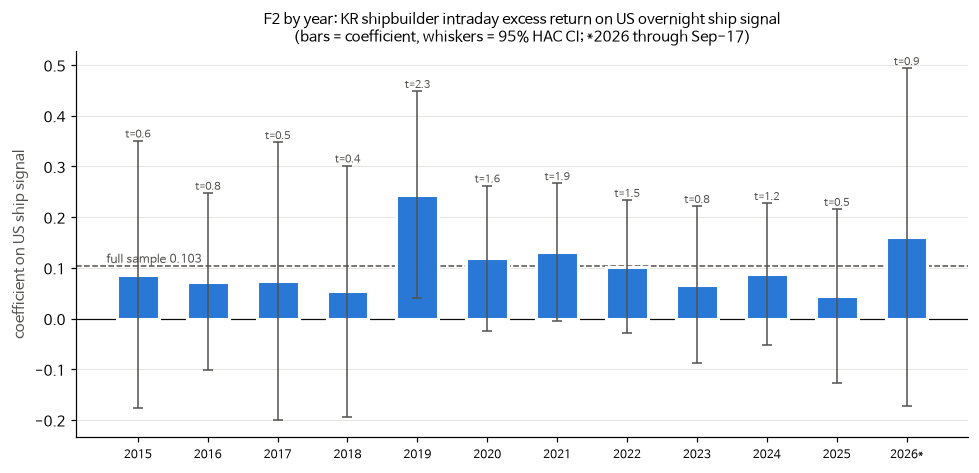

In [11]:
# ---- Step 2-1. 연도별 F2 계수 + 한 해 제외 / 영향 큰 두 해 제외 ----
X3 = ["us_ship", "spx", "brent"]
def f2(Fd, cols=X3, target="ship_intra_ex"):
    res = hac_ols(Fd[target], Fd[cols])
    return {"coef": res.params["us_ship"], "HAC t": res.tvalues["us_ship"], "p": res.pvalues["us_ship"], "N": int(res.nobs)}
yrs = sorted(set(F.index.year))
yr_rows = [{"연도": y, **f2(F[F.index.year == y])} for y in yrs]
loo = [{"제외 연도": str(y), **f2(F[F.index.year != y])} for y in yrs]
tblY = pd.DataFrame(yr_rows).set_index("연도")
tblLOO = pd.DataFrame(loo).set_index("제외 연도")
top2 = tblLOO["HAC t"].nsmallest(2).index.tolist()
tblLOO.loc[" + ".join(top2) + " (t를 가장 많이 낮추는 두 해)"] = f2(F[~F.index.year.isin([int(y) for y in top2])])
tblY.to_csv(f"{RES_DIR}/S2_1_yearly_F2.csv", encoding="utf-8-sig")
tblLOO.to_csv(f"{RES_DIR}/S2_1_leave_year_out_F2.csv", encoding="utf-8-sig")
display(tblY); display(tblLOO)
DRIVEN = bool((tblLOO["HAC t"] < 1.96).any())
print(f"연도 제외 시 최소 t = {tblLOO['HAC t'].min():.2f} ({tblLOO['HAC t'].idxmin()}) → "
      + ("특정 연도가 결과를 끌고 감" if DRIVEN else "어느 한 해 또는 두 해를 빼도 t ≥ 1.96 유지"))

# 그림: 연도별 계수 ± 1.96·SE (HAC). 단일 계열 → 범례 없음, 제목이 계열을 설명
BLUE, INK, INK2, GRID = "#2a78d6", "#0b0b0b", "#52514e", "#e4e3df"
se = tblY["coef"] / tblY["HAC t"]
fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(tblY))
ax.bar(x, tblY["coef"], width=0.6, color=BLUE, edgecolor="white", linewidth=2, zorder=2)
ax.errorbar(x, tblY["coef"], yerr=1.96 * se, fmt="none", ecolor=INK2, elinewidth=1, capsize=3, zorder=3)
ax.axhline(0, color=INK, lw=0.8, zorder=1)
full = tblF1.loc[("ship_intra_ex", "us_ship"), "coef"]
ax.axhline(full, color=INK2, lw=1, ls="--", zorder=1)
ax.text(-0.45, full, f"full sample {full:.3f}", va="bottom", ha="left", fontsize=8, color=INK2)
for xi, (b, t) in enumerate(zip(tblY["coef"], tblY["HAC t"])):
    ax.text(xi, (b + 1.96 * se.iloc[xi]) if b >= 0 else (b - 1.96 * se.iloc[xi]), f"t={t:.1f}", ha="center",
            va="bottom" if b >= 0 else "top", fontsize=7, color=INK2)
lbl = [f"{y}" + ("*" if y == yrs[-1] else "") for y in tblY.index]
ax.set_xticks(x); ax.set_xticklabels(lbl, fontsize=8)
ax.set_ylabel("coefficient on US ship signal", color=INK2)
ax.set_title("F2 by year: KR shipbuilder intraday excess return on US overnight ship signal\n(bars = coefficient, whiskers = 95% HAC CI; *2026 through Sep-17)", fontsize=10)
ax.grid(axis="y", color=GRID, lw=0.6, zorder=0); ax.set_axisbelow(True)
for s_ in ["top", "right"]: ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_F_yearly.png", bbox_inches="tight"); plt.show()

In [12]:
# ---- Step 2-2. 신호 구성 민감도 / Step 2-3. 2020년 말 기준 전·후반 ----
VARS = {"LNG·HII·ZIM (원래)": ["LNG", "HII", "ZIM"], "ZIM 제외 (LNG·HII)": ["LNG", "HII"],
        "LNG만": ["LNG"], "HII만": ["HII"], "ZIM만 (2021-01 상장 후)": ["ZIM"]}
rows = []
for lab, cols in VARS.items():
    Fv = make_F(B, cols)
    r_i, r_g = f2(Fv), f2(Fv, target="ship_gap_ex")
    rows.append({"신호 구성": lab, "장중 coef": r_i["coef"], "장중 HAC t": r_i["HAC t"], "장중 p": r_i["p"], "N": r_i["N"],
                 "(참고) 갭 coef": r_g["coef"], "(참고) 갭 t": r_g["HAC t"],
                 "표본 시작": Fv[["ship_intra_ex", "us_ship"]].dropna().index.min().date()})
tblSig = pd.DataFrame(rows).set_index("신호 구성")
tblSig.to_csv(f"{RES_DIR}/S2_2_signal_composition.csv", encoding="utf-8-sig"); display(tblSig)

tblHalf = pd.DataFrame([{"구간": "~2020-12-31", **f2(F.loc[:"2020-12-31"])},
                        {"구간": "2021-01-01~", **f2(F.loc["2021-01-01":])},
                        {"구간": "전체", **f2(F)}]).set_index("구간")
tblHalf.to_csv(f"{RES_DIR}/S2_3_split_2020.csv", encoding="utf-8-sig"); display(tblHalf)

,장중 coef,장중 HAC t,장중 p,N,(참고) 갭 coef,(참고) 갭 t,표본 시작
신호 구성,,,,,,,
LNG·HII·ZIM (원래),0.1029,3.6768,0.0002,2780,0.0224,1.5384,2015-01-06
ZIM 제외 (LNG·HII),0.1162,3.0822,0.0021,2780,0.0539,2.9220,2015-01-06
LNG만,0.0608,2.7125,0.0067,2780,0.0224,1.8386,2015-01-06
HII만,0.0578,1.6790,0.0932,2780,0.0332,2.5702,2015-01-06
ZIM만 (2021-01 상장 후),0.0206,1.4164,0.1567,1334,-0.0048,-0.7113,2021-02-01


,coef,HAC t,p,N
구간,,,,
~2020-12-31,0.1070,2.4152,0.0157,1427
2021-01-01~,0.0979,2.6913,0.0071,1353
전체,0.1029,3.6768,0.0002,2780


---
## Step 3. 거래세 없는 ETF로 우회하면 남는가
**가설**: F 신호 자체는 유효하고, 손실은 주식 매도 거래세 때문이다. 거래세가 없는 ETF로 같은 규칙을 실행하면 비용 후 수익이 남는다.

- 규칙: F3와 동일 — 신호(us_ship − S&P500)의 확장 백분위(최소 250일)가 0.8 이상인 날 시가 매수 → 종가 매도
- 비용 (미리 정한 값): 수수료 매수·매도 각 0.015%, 거래세 0(면제 확인 시), 왕복 스프레드 {0.05%, 0.10%, 0.20%}
- 주 ETF 선정 규칙 (미리 정함): 1배 조선 ETF 중 일평균 거래대금 중앙값(수정 전 종가 × 거래량, 상장일 ~ 2026-09-17) 10억원 이상인 것 중 상장일이 가장 빠른 것. 레버리지·인버스는 노출이 달라 대상에서 뺌.
- (A) 시뮬레이션: 2015~ 전체, 원 Part F 조선 바스켓(4종목 동일가중) 장중 수익률에 ETF 비용 적용
- (B) 실제 ETF: 상장일 이후, ETF의 실제 시가·종가
- 검정 (사전 지정): 신호일 비용 후 수익의 평균 = 0 (HAC 5), (A) 3개·(B) 3개·주식 바스켓 1개 = 7개

In [13]:
# ---- Step 3-0. ETF 세제와 후보 ----
TAX = pd.DataFrame([
    {"항목": "국내 상장 주식형 ETF 매도 — 증권거래세", "2026년 기준": "면제 (부과 안 됨)",
     "출처": "KB증권 'ETF 세금'(2025-07 작성·갱신): 'ETF 매도 시 증권거래세는 내지 않고…' https://kbthink.com/etf/etf-tax.html ; "
             "차호중 칼럼(2025-12-19): 'ETF는 법적으로 펀드(수익증권)에 가깝기 때문에 … 증권거래세는 대부분 면제' https://v.daum.net/v/20251219152204458",
     "비고": "법 조문 원문은 직접 확인하지 못함. 국내 주식형 ETF 매매차익도 비과세(분배금은 15.4%)"},
    {"항목": "코스피 주식 매도 — 증권거래세+농특세", "2026년 기준": "0.20% (0.05% + 0.15%)",
     "출처": "네이트 뉴스 2025-12-01 https://news.nate.com/view/20251201n26338", "비고": "Part I·J와 같은 가정"}])
TAX.to_csv(f"{RES_DIR}/S3_0_tax.csv", index=False, encoding="utf-8-sig"); display(TAX)

lst = requests.get("https://finance.naver.com/api/sise/etfItemList.nhn", params={"etfType": 0}, headers=HDR, timeout=15).json()
ETFS = {it["itemcode"]: it["itemname"] for it in lst["result"]["etfItemList"] if "조선" in it["itemname"]}
rows, ERAW = [], {}
for c, nm in ETFS.items():
    a = requests.get(f"https://m.stock.naver.com/api/stock/{c}/etfAnalysis", headers=HDR, timeout=15).json()
    rw = naver_raw_daily(c)
    ERAW[c] = rw
    t = rw.loc[:F_END]; t = t[t["vol"] > 0]
    top = a.get("etfTop10MajorConstituentAssets") or []
    rows.append({"code": c, "ETF": nm, "운용사": a.get("issuerName"), "기초지수": a.get("etfBaseIndex"),
                 "상장일": pd.to_datetime(a.get("listedDate")).date() if a.get("listedDate") else None,
                 "데이터 시작": t.index.min().date() if len(t) else None, "거래일(~09-17)": len(t),
                 "거래대금 중앙값(억원)": float((t["close"] * t["vol"]).median() / 1e8) if len(t) else np.nan,
                 "총보수(%)": a.get("totalFee"),
                 "구성 상위 5 (비중, 현재)": ", ".join(f"{x['itemName']} {x['etfWeight']}" for x in top[:5]),
                 "레버리지·인버스": bool(re.search("레버리지|인버스", nm))})
    time.sleep(0.3)
ETFT = pd.DataFrame(rows).sort_values("상장일").set_index("code")
elig = ETFT[(ETFT["거래대금 중앙값(억원)"] >= 10) & ~ETFT["레버리지·인버스"]]
ETF = elig.sort_values("상장일").index[0]
ETFT["주 ETF"] = ETFT.index == ETF
ETFT.to_csv(f"{RES_DIR}/S3_0_etf_candidates.csv", encoding="utf-8-sig"); display(ETFT)
print(f"주 ETF: {ETF} {ETFS[ETF]} (상장 {ETFT.loc[ETF, '상장일']}, 거래대금 중앙값 {ETFT.loc[ETF, '거래대금 중앙값(억원)']:.1f}억원)")
print("※ 구성 비중은 네이버 기준 현재 값(2026-09 말). 과거 구성은 달랐을 수 있음")

,항목,2026년 기준,출처,비고
0,국내 상장 주식형 ETF 매도 — 증권거래세,면제 (부과 안 됨),KB증권 'ETF 세금'(2025-07 작성·갱신): 'ETF 매도 시 증권거래세는 내지 않고…' https://kbthink.com/e...,법 조문 원문은 직접 확인하지 못함. 국내 주식형 ETF 매매차익도 비과세(분배금은 15.4%)
1,코스피 주식 매도 — 증권거래세+농특세,0.20% (0.05% + 0.15%),네이트 뉴스 2025-12-01 https://news.nate.com/view/20251201n26338,Part I·J와 같은 가정


,ETF,운용사,기초지수,상장일,데이터 시작,거래일(~09-17),거래대금 중앙값(억원),총보수(%),"구성 상위 5 (비중, 현재)",레버리지·인버스,주 ETF
code,,,,,,,,,,,
441540,HANARO Fn조선해운,NH-Amundi자산운용,FnGuide 조선해운지수,2022-09-15,2022-09-15,980,13.5785,0.4500,"HMM 19.06%, HD한국조선해양 15.03%, 삼성중공업 13.41%, 한화오션 12.39%, HD현대중공업 11.84%",False,True
445150,KODEX 친환경조선해운액티브,삼성자산운용(ETF),FnGuide K-친환경선박 지수,2022-11-15,2022-11-15,939,6.3567,0.5000,"팬오션 8.23%, HD한국조선해양 7.66%, HMM 7.60%, 삼성중공업 7.16%, 동성화인텍 7.12%",False,False
466920,SOL 조선TOP3플러스,신한자산운용,FnGuide 조선TOP3플러스지수(PR),2023-10-05,2023-10-05,720,414.5601,0.4500,"삼성중공업 25.14%, HD현대중공업 24.23%, 한화오션 24.16%, HD한국조선해양 14.57%, HD현대마린솔루션 4.60%",False,False
494670,TIGER 조선TOP10,미래에셋자산운용,iSelect 조선TOP10 Index(PR),2024-10-22,2024-10-22,466,299.1830,0.3500,"한화오션 22.14%, HD현대중공업 21.91%, HD한국조선해양 21.24%, 삼성중공업 15.98%, HD현대마린솔루션 9.93%",False,False
0080Y0,SOL 조선TOP3플러스레버리지,신한자산운용,FnGuide 조선 TOP3 플러스레버리지(2x) 지수,2025-07-15,2025-07-15,289,138.6154,0.5000,"삼성중공업 27.23%, HD현대중공업 26.26%, 한화오션 26.16%, HD한국조선해양 15.78%, HD현대마린솔루션 4.97%",True,False
0115D0,KODEX 조선TOP10,삼성자산운용(ETF),KRX 조선 TOP10 지수,2025-10-28,2025-10-28,220,150.5669,0.4500,"HD현대중공업 22.14%, HD한국조선해양 21.69%, 한화오션 21.06%, 삼성중공업 19.50%, 한화엔진 6.42%",False,False
0141S0,SOL 조선기자재,신한자산운용,FnGuide 조선기자재 지수(PR),2025-12-16,2025-12-16,185,36.7865,0.4500,"HD현대마린솔루션 24.77%, 한화엔진 21.29%, 한국카본 16.88%, HD현대마린엔진 10.87%, 대한조선 8.88%",False,False


주 ETF: 441540 HANARO Fn조선해운 (상장 2022-09-15, 거래대금 중앙값 13.6억원)
※ 구성 비중은 네이버 기준 현재 값(2026-09 말). 과거 구성은 달랐을 수 있음


In [14]:
# ---- Step 3-1~3-3. (A) 시뮬레이션 / (B) 실제 ETF ----
e = ERAW[ETF].loc[:F_END].copy()
try:
    ea = stock.get_market_ohlcv("20150101", F_END.replace("-", ""), ETF); ea.index = pd.to_datetime(ea.index)
    print("ETF 수정(pykrx) vs 수정 전(네이버 모바일) 종가 최대 차이(%):", float(((ea["종가"] / e["close"].reindex(ea.index)) - 1).abs().max() * 100))
except Exception as ex:
    print("pykrx ETF 시세 확인 실패:", ex)
e_ok = (e["vol"] > 0) & (e["open"] > 0)
print("ETF 저가 ≤ 시가 ≤ 고가 위반:", int((((e["open"] < e["low"]) | (e["open"] > e["high"])) & e_ok).sum()), "일")
etf_intra = (e["close"] / e["open"] - 1).where(e_ok).reindex(CAL)
E0 = e.index[e_ok][0]

COMM = 2 * 0.00015
SPREADS = [0.0005, 0.0010, 0.0020]
on_etf = on.where(etf_intra.notna(), 0.0)
def run(ret, onv, rt, name, start=None):
    g = (onv * ret.fillna(0)).loc[start:]
    n = (g - onv.loc[start:] * rt)
    tr = n[onv.loc[start:] > 0]
    res = sm.OLS(tr.values, np.ones(len(tr))).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
    m = metrics(n, name)
    return {**m, "신호일 평균 장중(%)": ret[onv > 0].loc[start:].mean() * 100, "왕복 비용(%)": rt * 100,
            "신호일 비용 후 평균(%)": tr.mean() * 100, "t (비용 후 = 0)": float(res.tvalues[0]), "p": float(res.pvalues[0]),
            "거래 일수": int((onv.loc[start:] > 0).sum()), "기간": f"{n.index[0].date()} ~ {n.index[-1].date()}"}, n
rows, NET = [], {}
spec = [("주식 바스켓 (거래세 0.20%, 2026)", F["ship_intra"], on, COST_BUY + COST_SELL_2026, None, True),
        ("(참고) 주식 바스켓, 원 노트북 비용 0.18%", F["ship_intra"], on, COST_BUY + COST_SELL, None, False)]
spec += [(f"(A) ETF 시뮬레이션, 스프레드 {s*100:.2f}%", F["ship_intra"], on, COMM + s, None, True) for s in SPREADS]
spec += [(f"(B) 실제 ETF {ETF}, 스프레드 {s*100:.2f}%", etf_intra, on_etf, COMM + s, E0, True) for s in SPREADS]
spec += [("(참고) 같은 기간 주식 바스켓 (거래세 0.20%)", F["ship_intra"], on, COST_BUY + COST_SELL_2026, E0, False),
         ("(참고) 같은 기간 (A) 시뮬레이션, 스프레드 0.10%", F["ship_intra"], on, COMM + 0.0010, E0, False),
         ("(참고) 비용 0 — 주식 바스켓 전체", F["ship_intra"], on, 0.0, None, False),
         (f"(참고) 비용 0 — 실제 ETF {ETF}", etf_intra, on_etf, 0.0, E0, False)]
# (참고·사후) 순수 조선 ETF: 규칙상 주 ETF는 아니지만 해운 편입 여부의 영향을 보기 위해 표시만 함 (검정 아님)
REF = "466920"
if REF in ERAW and REF != ETF:
    er = ERAW[REF].loc[:F_END]; ok_r = (er["vol"] > 0) & (er["open"] > 0)
    ref_intra = (er["close"] / er["open"] - 1).where(ok_r).reindex(CAL)
    on_ref = on.where(ref_intra.notna(), 0.0); R0 = er.index[ok_r][0]
    spec += [(f"(참고·사후) {ETFS[REF]} {REF}, 비용 0", ref_intra, on_ref, 0.0, R0, False),
             (f"(참고·사후) {ETFS[REF]} {REF}, 스프레드 0.10%", ref_intra, on_ref, COMM + 0.0010, R0, False),
             ("(참고) 같은 기간 주식 바스켓 — " + REF + " 상장 이후 (거래세 0.20%)", F["ship_intra"], on, COST_BUY + COST_SELL_2026, R0, False)]
for name, ret, onv, rt, st, is_test in spec:
    m, n = run(ret, onv, rt, name, st); m["사전 지정 검정"] = is_test; rows.append(m); NET[name] = n
CMP3 = pd.DataFrame(rows).set_index("strategy")
cols3 = ["기간", "거래 일수", "신호일 평균 장중(%)", "왕복 비용(%)", "신호일 비용 후 평균(%)", "CAGR(%)", "Sharpe", "MDD(%)",
         "t (비용 후 = 0)", "p", "사전 지정 검정"]
CMP3 = CMP3[cols3]
CMP3.to_csv(f"{RES_DIR}/S3_4_comparison.csv", encoding="utf-8-sig"); display(CMP3)

# 추적 차이: 겹치는 기간, 신호일의 바스켓 장중 vs ETF 장중
ov = pd.DataFrame({"basket": F["ship_intra"], "etf": etf_intra}).loc[E0:].dropna()
ovs = ov[on.reindex(ov.index) > 0]
TRK = pd.DataFrame([{"구간": "신호일", "일수": len(ovs), "상관": ovs.corr().iloc[0, 1],
                     "평균 바스켓(%)": ovs["basket"].mean() * 100, "평균 ETF(%)": ovs["etf"].mean() * 100,
                     "평균 차이 ETF − 바스켓(%p)": (ovs["etf"] - ovs["basket"]).mean() * 100,
                     "차이 표준편차(%p)": (ovs["etf"] - ovs["basket"]).std() * 100},
                    {"구간": "전체 거래일", "일수": len(ov), "상관": ov.corr().iloc[0, 1],
                     "평균 바스켓(%)": ov["basket"].mean() * 100, "평균 ETF(%)": ov["etf"].mean() * 100,
                     "평균 차이 ETF − 바스켓(%p)": (ov["etf"] - ov["basket"]).mean() * 100,
                     "차이 표준편차(%p)": (ov["etf"] - ov["basket"]).std() * 100}]).set_index("구간")
TRK.index = [f"{ETF} {i}" for i in TRK.index]
if REF in ERAW and REF != ETF:
    ov2 = pd.DataFrame({"basket": F["ship_intra"], "etf": ref_intra}).loc[R0:].dropna(); ovs2 = ov2[on.reindex(ov2.index) > 0]
    TRK.loc[f"(참고·사후) {REF} 신호일"] = [len(ovs2), ovs2.corr().iloc[0, 1], ovs2["basket"].mean() * 100, ovs2["etf"].mean() * 100,
                                        (ovs2["etf"] - ovs2["basket"]).mean() * 100, (ovs2["etf"] - ovs2["basket"]).std() * 100]
TRK.to_csv(f"{RES_DIR}/S3_3_tracking.csv", encoding="utf-8-sig"); display(TRK)

# Corwin-Schultz(2012) 2일 고가·저가 스프레드 추정 (참고, 음수는 0)
h, l = e["high"].where(e_ok), e["low"].where(e_ok)
beta = np.log(h / l) ** 2 + np.log(h.shift(-1) / l.shift(-1)) ** 2
gamma = np.log(np.maximum(h, h.shift(-1)) / np.minimum(l, l.shift(-1))) ** 2
k = 3 - 2 * np.sqrt(2)
alpha = (np.sqrt(2 * beta) - np.sqrt(beta)) / k - np.sqrt(gamma / k)
CS = (2 * (np.exp(alpha) - 1) / (1 + np.exp(alpha))).clip(lower=0).dropna()
CS_tbl = pd.DataFrame([{"구간": lab, "일수": len(x), "평균(%)": x.mean() * 100, "중앙값(%)": x.median() * 100}
                       for lab, x in [("상장 이후 전체", CS), ("최근 1년", CS.loc[CS.index.max() - pd.Timedelta(days=365):]),
                                      ("신호일", CS[CS.index.isin(on[on > 0].index)])]]).set_index("구간")
tick = e["close"].median()
print(f"참고: ETF 가격 중앙값 {tick:,.0f}원, 호가 단위 5원(2,000원 이상 ETF) → 최소 스프레드 약 {5/tick*100:.3f}%")
CS_tbl.to_csv(f"{RES_DIR}/S3_2_corwin_schultz.csv", encoding="utf-8-sig"); display(CS_tbl)
if (CMP3["거래 일수"].loc[[i for i in CMP3.index if i.startswith("(B)")]] < 50).any():
    print("※ 실제 ETF 거래 일수가 50일 미만 — 통계적 판단이 어려움")

ETF 수정(pykrx) vs 수정 전(네이버 모바일) 종가 최대 차이(%): 1.9334719334719308
ETF 저가 ≤ 시가 ≤ 고가 위반: 0 일


,기간,거래 일수,신호일 평균 장중(%),왕복 비용(%),신호일 비용 후 평균(%),CAGR(%),Sharpe,MDD(%),t (비용 후 = 0),p,사전 지정 검정
strategy,,,,,,,,,,,
"주식 바스켓 (거래세 0.20%, 2026)",2015-01-02 ~ 2026-09-17,598,0.2364,0.2300,0.0064,-1.3785,-0.0743,-39.2738,0.0691,0.9449,True
"(참고) 주식 바스켓, 원 노트북 비용 0.18%",2015-01-02 ~ 2026-09-17,598,0.2364,0.1800,0.0564,1.2412,0.0669,-30.7954,0.6069,0.5439,False
"(A) ETF 시뮬레이션, 스프레드 0.05%",2015-01-02 ~ 2026-09-17,598,0.2364,0.0800,0.1564,6.6871,0.3600,-25.2289,1.6826,0.0924,True
"(A) ETF 시뮬레이션, 스프레드 0.10%",2015-01-02 ~ 2026-09-17,598,0.2364,0.1300,0.1064,3.9292,0.2117,-28.0653,1.1448,0.2523,True
"(A) ETF 시뮬레이션, 스프레드 0.20%",2015-01-02 ~ 2026-09-17,598,0.2364,0.2300,0.0064,-1.3785,-0.0743,-39.2738,0.0691,0.9449,True
"(B) 실제 ETF 441540, 스프레드 0.05%",2022-09-15 ~ 2026-09-17,215,0.0885,0.0800,0.0085,-0.7133,-0.0463,-23.2515,0.0690,0.9450,True
"(B) 실제 ETF 441540, 스프레드 0.10%",2022-09-15 ~ 2026-09-17,215,0.0885,0.1300,-0.0415,-3.4219,-0.2219,-26.0504,-0.3363,0.7366,True
"(B) 실제 ETF 441540, 스프레드 0.20%",2022-09-15 ~ 2026-09-17,215,0.0885,0.2300,-0.1415,-8.6231,-0.5582,-35.0293,-1.1470,0.2514,True
(참고) 같은 기간 주식 바스켓 (거래세 0.20%),2022-09-15 ~ 2026-09-17,215,0.1477,0.2300,-0.0823,-6.2099,-0.3219,-33.4233,-0.5356,0.5923,False


,일수,상관,평균 바스켓(%),평균 ETF(%),평균 차이 ETF − 바스켓(%p),차이 표준편차(%p)
441540 신호일,215.0000,0.9371,0.1477,0.0885,-0.0591,0.9743
441540 전체 거래일,980.0000,0.9304,-0.0565,-0.0814,-0.0249,0.9443
(참고·사후) 466920 신호일,176.0000,0.9701,0.1934,0.1852,-0.0082,0.6657


참고: ETF 가격 중앙값 13,128원, 호가 단위 5원(2,000원 이상 ETF) → 최소 스프레드 약 0.038%


,일수,평균(%),중앙값(%)
구간,,,
상장 이후 전체,979,0.6182,0.1147
최근 1년,244,0.7550,0.0000
신호일,215,0.6467,0.1427


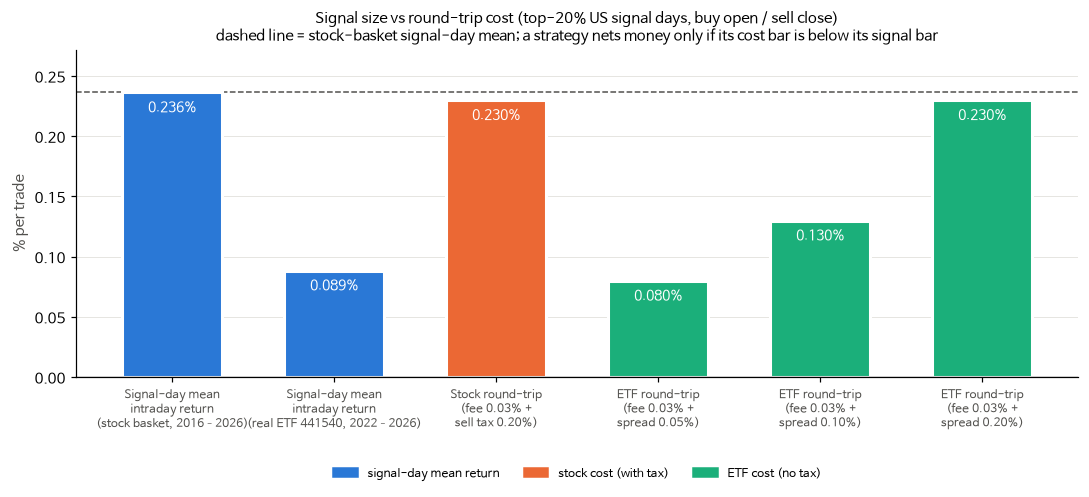

In [15]:
# ---- Step 3-5. 발표용: 신호 크기 vs 왕복 비용 ----
ORANGE, AQUA = "#eb6834", "#1baf7a"
sig_mean = CMP3.loc["주식 바스켓 (거래세 0.20%, 2026)", "신호일 평균 장중(%)"]
etf_real = CMP3.loc[f"(B) 실제 ETF {ETF}, 스프레드 0.10%", "신호일 평균 장중(%)"]
bars = [("Signal-day mean\nintraday return\n(stock basket, 2016–2026)", sig_mean, BLUE),
        (f"Signal-day mean\nintraday return\n(real ETF {ETF}, {E0.year}–2026)", etf_real, BLUE),
        ("Stock round-trip\n(fee 0.03% +\nsell tax 0.20%)", (COST_BUY + COST_SELL_2026) * 100, ORANGE)]
bars += [(f"ETF round-trip\n(fee 0.03% +\nspread {s*100:.2f}%)", (COMM + s) * 100, AQUA) for s in SPREADS]
fig, ax = plt.subplots(figsize=(10, 4.8))
xs = np.arange(len(bars))
ax.bar(xs, [b[1] for b in bars], width=0.62, color=[b[2] for b in bars], edgecolor="white", linewidth=2, zorder=2)
for xi, (lab, v, col) in enumerate(bars):
    ax.text(xi, v - 0.006, f"{v:.3f}%", ha="center", va="top", fontsize=9, color="white", fontweight="bold")
ax.axhline(sig_mean, color=INK2, lw=1, ls="--", zorder=1)
ax.axhline(0, color=INK, lw=0.8)
ax.set_xticks(xs); ax.set_xticklabels([b[0] for b in bars], fontsize=8, color=INK2)
ax.set_ylabel("% per trade", color=INK2)
ax.set_title("Signal size vs round-trip cost (top-20% US signal days, buy open / sell close)\n"
             "dashed line = stock-basket signal-day mean; a strategy nets money only if its cost bar is below its signal bar", fontsize=10)
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=BLUE, label="signal-day mean return"), Patch(color=ORANGE, label="stock cost (with tax)"),
                   Patch(color=AQUA, label="ETF cost (no tax)")], fontsize=8, frameon=False, loc="upper center",
          bbox_to_anchor=(0.5, -0.24), ncol=3)
ax.set_ylim(0, max(b[1] for b in bars) * 1.15)
ax.grid(axis="y", color=GRID, lw=0.6, zorder=0); ax.set_axisbelow(True)
for s_ in ["top", "right"]: ax.spines[s_].set_visible(False)
plt.tight_layout(); plt.savefig(f"{RES_DIR}/fig_cost_barrier.png", bbox_inches="tight"); plt.show()

---
## Step 4. 두 주제를 잇는 검정 (사전 지정, 1개)
**가설**: 조선 동조화가 높을 때 미국 신호가 더 강하게 전달된다.
- 테마 강도: Part A 강건성 점검의 **V1 대형 3사 고정 버전** (`results/robust_A/RA1_theme_series.csv`의 `regime V1 big3`, 60일 평균 쌍별 상관의 확장 백분위 ≥ 0.8 = High). 읽기만 함.
- High_t = **전날(t−1)** 레짐이 High. V1이 계산되지 않는 날(한화오션 정지 구간 등)은 제외.
- 회귀: 조선 장중 초과수익 = a + b·신호 + c·(신호 × High) + d·High + e·S&P500 + 오차, HAC(5). 신호 = us_ship − S&P500 (원 Part F 정의).
- **판정은 c 하나로만.** 다른 변형은 돌리지 않음.

In [16]:
# ---- Step 4. 동조화 High × 신호 ----
ra1 = pd.read_csv("results/robust_A/RA1_theme_series.csv", parse_dates=["Date"]).set_index("Date")
reg = ra1["regime V1 big3"].reindex(CAL)
high_prev = reg.shift(1)
d4 = pd.DataFrame({"y": F["ship_intra_ex"], "signal": F["signal"], "spx": F["spx"], "reg_prev": high_prev}).dropna()
d4["High"] = (d4["reg_prev"] == "High").astype(float)
d4["signal_x_High"] = d4["signal"] * d4["High"]
res4 = sm.OLS(d4["y"], sm.add_constant(d4[["signal", "signal_x_High", "High", "spx"]])).fit(cov_type="HAC", cov_kwds={"maxlags": 5})
T4 = pd.DataFrame({"coef": res4.params, "HAC t": res4.tvalues, "p": res4.pvalues})
T4.to_csv(f"{RES_DIR}/S4_theme_interaction.csv", encoding="utf-8-sig"); display(T4)
print(f"N = {int(res4.nobs)}, High 일수 = {int(d4['High'].sum())} ({d4['High'].mean()*100:.1f}%), 표본 {d4.index.min().date()} ~ {d4.index.max().date()}")
print(f"판정 대상 c(신호 × High) = {res4.params['signal_x_High']:.4f}, t = {res4.tvalues['signal_x_High']:.2f}, p = {res4.pvalues['signal_x_High']:.3f}")
print(f"참고: Low·Mid일 신호 계수 b = {res4.params['signal']:.4f}, High일 신호 계수 b + c = {res4.params['signal'] + res4.params['signal_x_High']:.4f}")

,coef,HAC t,p
const,0.0002,0.4129,0.6797
signal,0.1160,3.7901,0.0002
signal_x_High,0.0564,0.7854,0.4322
High,-0.0004,-0.3959,0.6921
spx,-0.0446,-1.0673,0.2859


N = 2145, High 일수 = 497 (23.2%), 표본 2016-04-04 ~ 2026-09-17
판정 대상 c(신호 × High) = 0.0564, t = 0.79, p = 0.432
참고: Low·Mid일 신호 계수 b = 0.1160, High일 신호 계수 b + c = 0.1724


In [17]:
# ---- 이번 노트북의 새 검정 수와 다중검정 기준 ----
TT = pd.DataFrame([
    {"단계": "1-5 제외 후 F1·F2 재추정", "검정 수": 2, "최소 p / 비고": f"F2 t = {t_x.loc[('ship_intra_ex','us_ship'),'HAC t']:.2f}"},
    {"단계": "2-1 연도별 F2", "검정 수": len(tblY), "최소 p / 비고": f"{tblY['p'].min():.4f}"},
    {"단계": "2-1 한 해 제외·두 해 제외 F2", "검정 수": len(tblLOO), "최소 p / 비고": f"{tblLOO['p'].min():.2e}"},
    {"단계": "2-2 신호 구성 (원래 정의 제외)", "검정 수": len(tblSig) - 1, "최소 p / 비고": f"{tblSig['장중 p'].iloc[1:].min():.4f}"},
    {"단계": "2-3 전·후반", "검정 수": 2, "최소 p / 비고": f"{tblHalf['p'].iloc[:2].min():.4f}"},
    {"단계": "3 비용 후 평균 = 0 (사전 지정 7개)", "검정 수": int(CMP3["사전 지정 검정"].sum()),
     "최소 p / 비고": f"{CMP3.loc[CMP3['사전 지정 검정'], 'p'].min():.4f}"},
    {"단계": "4 동조화 × 신호 (c)", "검정 수": 1, "최소 p / 비고": f"{res4.pvalues['signal_x_High']:.4f}"}])
NT = int(TT["검정 수"].sum())
TT.loc[len(TT)] = {"단계": "합계", "검정 수": NT, "최소 p / 비고": f"Bonferroni 기준 p < {0.05/NT:.5f} (|t| > {stats.norm.ppf(1 - 0.025/NT):.2f})"}
TT.to_csv(f"{RES_DIR}/S5_test_count.csv", index=False, encoding="utf-8-sig"); display(TT)
print("※ Step 4는 사전 지정 단일 검정이라 단독으로는 p < 0.05가 기준. 노트북 전체 기준도 함께 보고함.")

,단계,검정 수,최소 p / 비고
0,1-5 제외 후 F1·F2 재추정,2,F2 t = 3.39
1,2-1 연도별 F2,12,0.0191
2,2-1 한 해 제외·두 해 제외 F2,13,1.78e-04
3,2-2 신호 구성 (원래 정의 제외),4,0.0021
4,2-3 전·후반,2,0.0071
5,3 비용 후 평균 = 0 (사전 지정 7개),7,0.0924
6,4 동조화 × 신호 (c),1,0.4322
7,합계,41,Bonferroni 기준 p < 0.00122 (|t| > 3.23)


※ Step 4는 사전 지정 단일 검정이라 단독으로는 p < 0.05가 기준. 노트북 전체 기준도 함께 보고함.
